# CSCI 3151 — M02 Mini-lab: Learning Settings in the Wild

In this mini-lab you will **contrast supervised, unsupervised, and semi-supervised learning** on a small, synthetic dataset.

We will play the role of a data scientist at an online learning platform deciding **which students are likely to subscribe** after a trial period.

We'll use:
- Supervised learning (labeled data only),
- Unsupervised learning (clustering everyone),
- A simple semi-supervised twist (using unlabeled points during training).


## Scenario: data-generating process (DGP) & stakeholders

- Each point is a student trial account.
- Features:
  - `time_on_platform_hours` — average hours spent per week (continuous; hours/week).
  - `avg_quiz_score` — average quiz score during the trial (0–100).
- Hidden label:
  - `will_subscribe` — 1 if the student converts to a paid plan, 0 otherwise.

**Stakeholders & decisions**

- Product team wants to decide **who gets a personalized nudge email**.
- False **negative** (we *don’t* nudge someone who would subscribe) → *lost opportunity but low harm*.
- False **positive** (we *do* nudge someone who will definitely not subscribe) → *small annoyance, reputation risk if overdone*.

We will start with a **supervised model** and then see what unlabeled data can/cannot buy us.


In [7]:
# Setup: imports and plotting defaults

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# Reproducibility
RNG_SEED = 3151
rng = np.random.default_rng(RNG_SEED)

plt.rcParams["figure.figsize"] = (5, 4)
plt.rcParams["axes.grid"] = True


In [29]:
# Construct a small synthetic dataset

n_pos = 160  # students who will subscribe
n_neg = 160  # students who will not subscribe

# Positives: more engaged + higher quiz scores
time_pos = rng.normal(5.0, 1.0, size=n_pos)      # hours/week
quiz_pos = rng.normal(80.0, 5.0, size=n_pos)     # /100

# Negatives: less engaged + lower quiz scores
time_neg = rng.normal(1.5, 0.7, size=n_neg)
quiz_neg = rng.normal(55.0, 7.0, size=n_neg)

X = np.vstack([
    np.column_stack([time_pos, quiz_pos]),
    np.column_stack([time_neg, quiz_neg]),
])
y = np.concatenate([
    np.ones(n_pos, dtype=int),
    np.zeros(n_neg, dtype=int)
])


df = pd.DataFrame({
    "time_on_platform_hours": X[:, 0],
    "avg_quiz_score": X[:, 1],
    "will_subscribe": y.astype(float),   # float so we can store NaNs for unlabeled
})

# Mark some users as unlabeled (e.g., subscription status not logged yet)
is_labeled = np.ones(len(df), dtype=bool)
unlabeled_idx = rng.choice(len(df), size=120, replace=False)
is_labeled[unlabeled_idx] = False

df["is_labeled"] = is_labeled
df.loc[~df["is_labeled"], "will_subscribe"] = np.nan

df.head()


,time_on_platform_hours,avg_quiz_score,will_subscribe,is_labeled
0,5.488884,84.449282,NaN,False
1,5.030641,80.300346,1.0,True
2,4.907952,88.136789,1.0,True
3,5.332473,89.720704,1.0,True
4,4.893690,76.764561,NaN,False


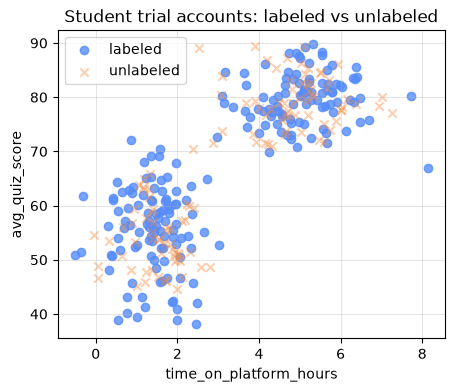

In [40]:
# Quick visualization: labeled vs unlabeled points

fig, ax = plt.subplots()

labeled = df[df["is_labeled"]]
unlabeled = df[~df["is_labeled"]]

ax.scatter(
    labeled["time_on_platform_hours"],
    labeled["avg_quiz_score"],
    label="labeled",
    alpha=0.8,
)
ax.scatter(
    unlabeled["time_on_platform_hours"],
    unlabeled["avg_quiz_score"],
    label="unlabeled",
    alpha=0.4,
    marker="x",
)

ax.set_xlabel("time_on_platform_hours")
ax.set_ylabel("avg_quiz_score")
ax.legend()
ax.set_title("Student trial accounts: labeled vs unlabeled")

plt.show()


## Core Task 1 — Supervised baseline (labeled data only)

In **supervised learning**, we assume access to pairs $(x_i, y_i)$ and learn a function $f_\theta(x)$ to predict $y$.

Here, we will:
1. Use only the **labeled** students.
2. Split them into **train** and **test** sets.
3. Train a **logistic regression** classifier.
4. Compute accuracy on the held-out test set.

> Concept: This approximates the **empirical risk minimization** objective covered in the video.


In [50]:
# TODO: build a supervised baseline using only labeled data

# 1. Select only labeled rows
labeled = df[df["is_labeled"]].copy()

X_labeled = labeled[["time_on_platform_hours", "avg_quiz_score"]].values
y_labeled = labeled["will_subscribe"].values.astype(int)

# 2. Train/test split
# TODO: experiment with different test_size values (e.g., 0.2, 0.3, 0.4).
# same as 0.25
X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_labeled,
    test_size=0.25,
    random_state=RNG_SEED,
    stratify=y_labeled,
)

# 3. Fit a logistic regression model
# TODO: try different C values (e.g., 0.1, 1.0, 10) and note what happens.
# same as 1.0
log_reg = LogisticRegression(
    C=0.3,
    random_state=RNG_SEED
)
log_reg.fit(X_train, y_train)

# 4. Evaluate on held-out test set
y_pred = log_reg.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Supervised baseline accuracy: {acc:.3f}")

assert 0.0 <= acc <= 1.0, "Accuracy must lie between 0 and 1."


Supervised baseline accuracy: 1.000


### Quick question (write in Markdown or discuss)

- If we changed the **decision problem** so that false positives were much more costly than false negatives, which metric(s) might be more appropriate than accuracy?
- How would that appear in code (e.g., what function from `sklearn.metrics` would you use)?


## Core Task 2 — Unsupervised clustering (ignoring labels)

Now imagine we had **no labels at all**.

In **unsupervised learning**, we try to discover structure in the $x_i$'s alone.

We will:
1. Ignore the subscription labels entirely.
2. Run **k-means clustering** on all students.
3. Visualize clusters and compare qualitatively to the labeled points.

> Concept: this approximates minimizing within-cluster variance, a typical unsupervised **distortion objective**.


Cluster sizes: [162 158]


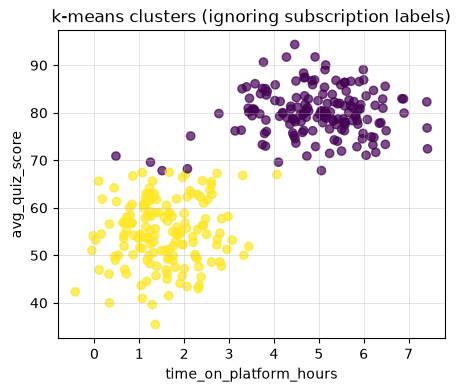

In [11]:
# TODO: run k-means clustering on ALL students (labeled + unlabeled)

X_all = df[["time_on_platform_hours", "avg_quiz_score"]].values

# 1. Fit k-means
# TODO: try different values of n_clusters (e.g., 2, 3, 4).
kmeans = KMeans(
    n_clusters=2,
    random_state=RNG_SEED,
    n_init=10,
)
cluster_labels = kmeans.fit_predict(X_all)

print("Cluster sizes:", np.bincount(cluster_labels))
assert len(cluster_labels) == len(df), "Every point must get a cluster label."

# 2. Visualize clusters
fig, ax = plt.subplots()
scatter = ax.scatter(
    df["time_on_platform_hours"],
    df["avg_quiz_score"],
    c=cluster_labels,
    alpha=0.7,
)

ax.set_xlabel("time_on_platform_hours")
ax.set_ylabel("avg_quiz_score")
ax.set_title("k-means clusters (ignoring subscription labels)")

plt.show()


### Discuss / jot down:

1. Do the clusters roughly align with the eventual subscription label?
2. What are some **valid uses** of this clustering in our product (even if we never see labels)?
3. What would be a **dangerous misuse** of these clusters?


## Core Task 3 — A simple semi-supervised twist (pseudo-labeling)

**Semi-supervised learning** assumes:
- A small set of labeled points, and
- A larger set of unlabeled points from the same distribution.

One simple (and imperfect) strategy is **pseudo-labeling**:
1. Train a supervised model on labeled data.
2. Use it to assign labels to unlabeled points where we are very confident.
3. Retrain the model on the union of labeled + confidently pseudo-labeled points.

We'll implement a toy version and compare to the pure supervised baseline.


In [13]:
# TODO: implement a very simple pseudo-labeling loop

# 1. Separate labeled and unlabeled feature matrices
labeled = df[df["is_labeled"]].copy()
unlabeled = df[~df["is_labeled"]].copy()

X_labeled = labeled[["time_on_platform_hours", "avg_quiz_score"]].values
y_labeled = labeled["will_subscribe"].values.astype(int)

X_unlabeled = unlabeled[["time_on_platform_hours", "avg_quiz_score"]].values

# 2. Fit a base supervised model (reuse log_reg or refit)
base_model = LogisticRegression(random_state=RNG_SEED)
base_model.fit(X_labeled, y_labeled)

# 3. Get predicted probabilities on unlabeled points
probs_unlabeled = base_model.predict_proba(X_unlabeled)

# 4. Choose a confidence threshold
# TODO: try different thresholds (e.g., 0.6, 0.8, 0.9).
threshold = 0.9

# 5. Build pseudo-labels where the model is confident
pseudo_labels = np.argmax(probs_unlabeled, axis=1)
max_probs = np.max(probs_unlabeled, axis=1)

confident_mask = max_probs >= threshold
X_pseudo = X_unlabeled[confident_mask]
y_pseudo = pseudo_labels[confident_mask]

print(f"Number of pseudo-labeled points: {len(X_pseudo)}")

# 6. Retrain a new model on labeled + pseudo-labeled
X_aug = np.vstack([X_labeled, X_pseudo])
y_aug = np.concatenate([y_labeled, y_pseudo])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_aug, y_aug,
    test_size=0.25,
    random_state=RNG_SEED,
    stratify=y_aug,
)

semi_supervised_model = LogisticRegression(random_state=RNG_SEED)
semi_supervised_model.fit(X_train2, y_train2)

y_pred2 = semi_supervised_model.predict(X_test2)
acc2 = accuracy_score(y_test2, y_pred2)
print(f"Semi-supervised (pseudo-labeling) accuracy: {acc2:.3f}")

assert 0.0 <= acc2 <= 1.0, "Accuracy must lie between 0 and 1."


Number of pseudo-labeled points: 116
Semi-supervised (pseudo-labeling) accuracy: 1.000


### Compare & interpret

- How does the semi-supervised accuracy compare to the pure supervised baseline?
- For which thresholds does performance get **worse**? Why?
- Conceptually, which **assumptions** need to hold for this simple pseudo-labeling trick to help?


## Stretch tasks (optional)

If you finish early, try one or more of:

1. **Alternative model**  
   Replace logistic regression with another classifier (e.g., `sklearn.svm.SVC`) and see how the story changes.

2. **Cluster-informed labeling**  
   Use clusters to define a new feature (e.g., one-hot cluster ID) and add it to the supervised model. Does it help?

3. **Self-supervised pretext idea**  
   Without writing code, describe in 2–3 sentences a plausible **self-supervised** task on this platform (e.g., predict
   one part of the student trajectory from another) and how it might improve downstream subscription prediction.


## Reflection (answer in your own words)

Use this cell (or your notes) to jot brief answers:

- Which **learning setting** (supervised / unsupervised / semi-supervised) felt most natural for this decision problem? Why?
-

- Which **assumption** do you now trust **less** than before doing the lab?
- What did the metrics you used **fail to capture** about model quality?
- If you had **10× more data** and compute, what experiment would you run next?
